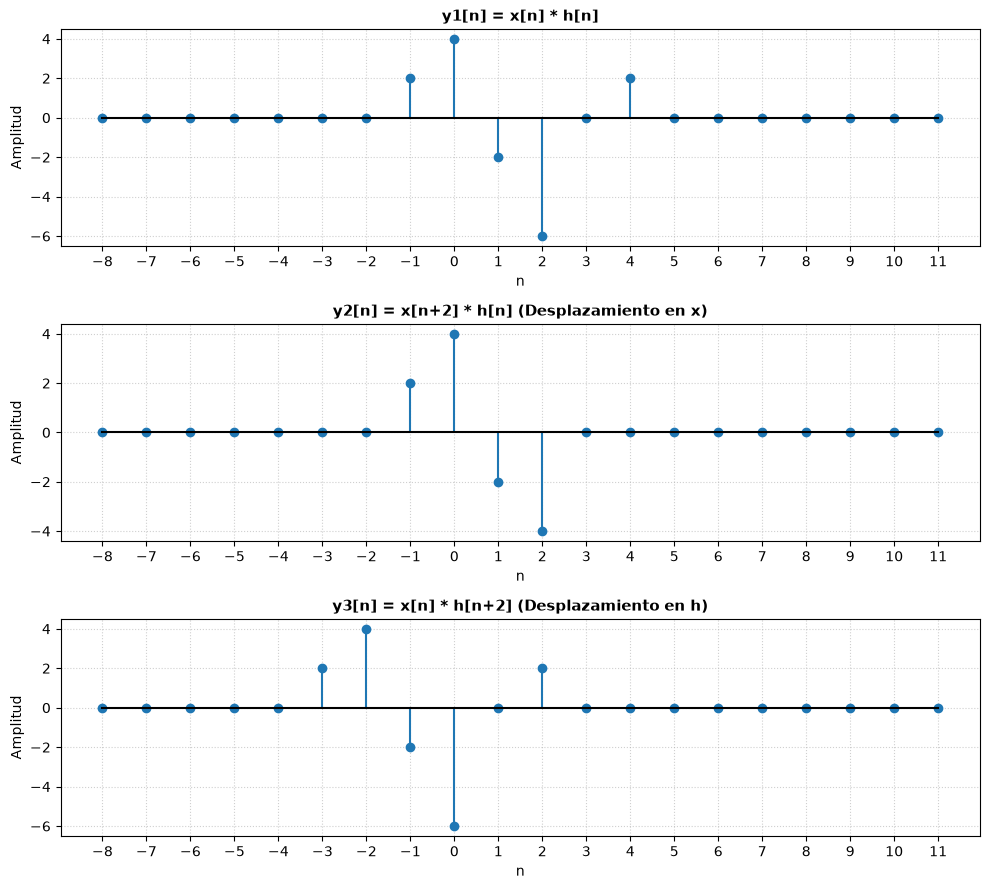

In [21]:
import matplotlib.pyplot as plt
import numpy as np

n_range = np.arange(-8, 12)

def x_sig(n):
    return (
        (n == 0).astype(float) + 2 * (n == 1).astype(float) - (n == 3).astype(float)
    )

def h_sig(n):
    return 2 * (n == -1).astype(float) - 2 * (n == 1).astype(float)

n_x = np.arange(0, 4)  
x_base = x_sig(n_x)

n_h = np.arange(-1, 2) 
h_base = h_sig(n_h)

y1_conv = np.convolve(x_base, h_base, mode="full")
n_y1 = np.arange(n_x[0] + n_h[0], n_x[-1] + n_h[-1] + 1)

n_x_shifted = n_x - 2
x_shifted_base = x_sig(n_x_shifted)  
y2_conv = np.convolve(x_shifted_base, h_base, mode="full")
n_y2 = np.arange(n_x_shifted[0] + n_h[0], n_x_shifted[-1] + n_h[-1] + 1)

n_h_shifted = n_h - 2
h_shifted_base = h_sig(n_h)
y3_conv = np.convolve(x_base, h_shifted_base, mode="full")
n_y3 = np.arange(n_x[0] + n_h_shifted[0], n_x[-1] + n_h_shifted[-1] + 1)

def map_to_range(n_src, y_src, n_dst):
    y_dst = np.zeros_like(n_dst, dtype=float)
    for n_val, val in zip(n_src, y_src):
        if n_val in n_dst:
            y_dst[n_dst == n_val] = val
    return y_dst

y1 = map_to_range(n_y1, y1_conv, n_range)
y2 = map_to_range(n_y2, y2_conv, n_range)
y3 = map_to_range(n_y3, y3_conv, n_range)

fig, axes = plt.subplots(3, 1, figsize=(10, 9))

titulos = [
    r"y1[n] = x[n] * h[n]",
    r"y2[n] = x[n+2] * h[n] (Desplazamiento en x)",
    r"y3[n] = x[n] * h[n+2] (Desplazamiento en h)",
]

senales = [y1, y2, y3]

for ax, sig, title in zip(axes, senales, titulos):
    ax.stem(n_range, sig, basefmt="k-")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("n")
    ax.set_ylabel("Amplitud")
    ax.set_xticks(n_range)
    ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

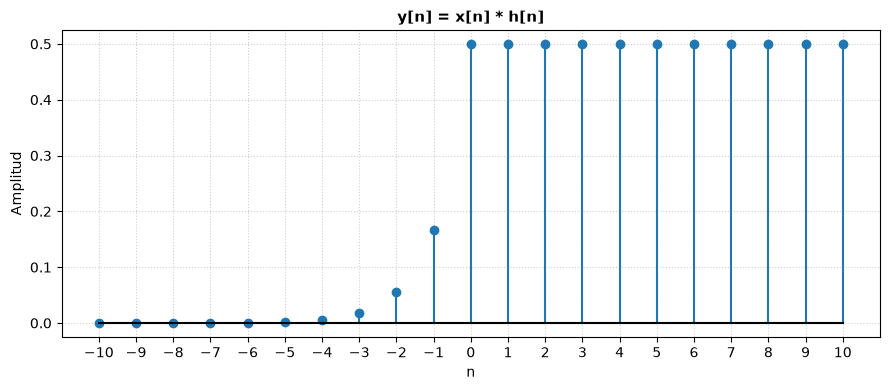

In [22]:
import matplotlib.pyplot as plt
import numpy as np

n_range = np.arange(-30, 30)

def x_sig(n):
    val = (1.0 / 3.0) ** (-n)
    u_step = (-n - 1 >= 0).astype(float)
    return val * u_step

def h_sig(n):
    return (n - 1 >= 0).astype(float)

x = x_sig(n_range)
h = h_sig(n_range)

y_full = np.convolve(x, h, mode="full")

n_y = np.arange(n_range[0] + n_range[0], n_range[-1] + n_range[-1] + 1)

mask = (n_y >= -10) & (n_y <= 10)

plt.figure(figsize=(9, 4))
plt.stem(n_y[mask], y_full[mask], basefmt="k-")
plt.title(r"y[n] = x[n] * h[n]", fontsize=11, fontweight="bold")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.xticks(np.arange(-10, 11))
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

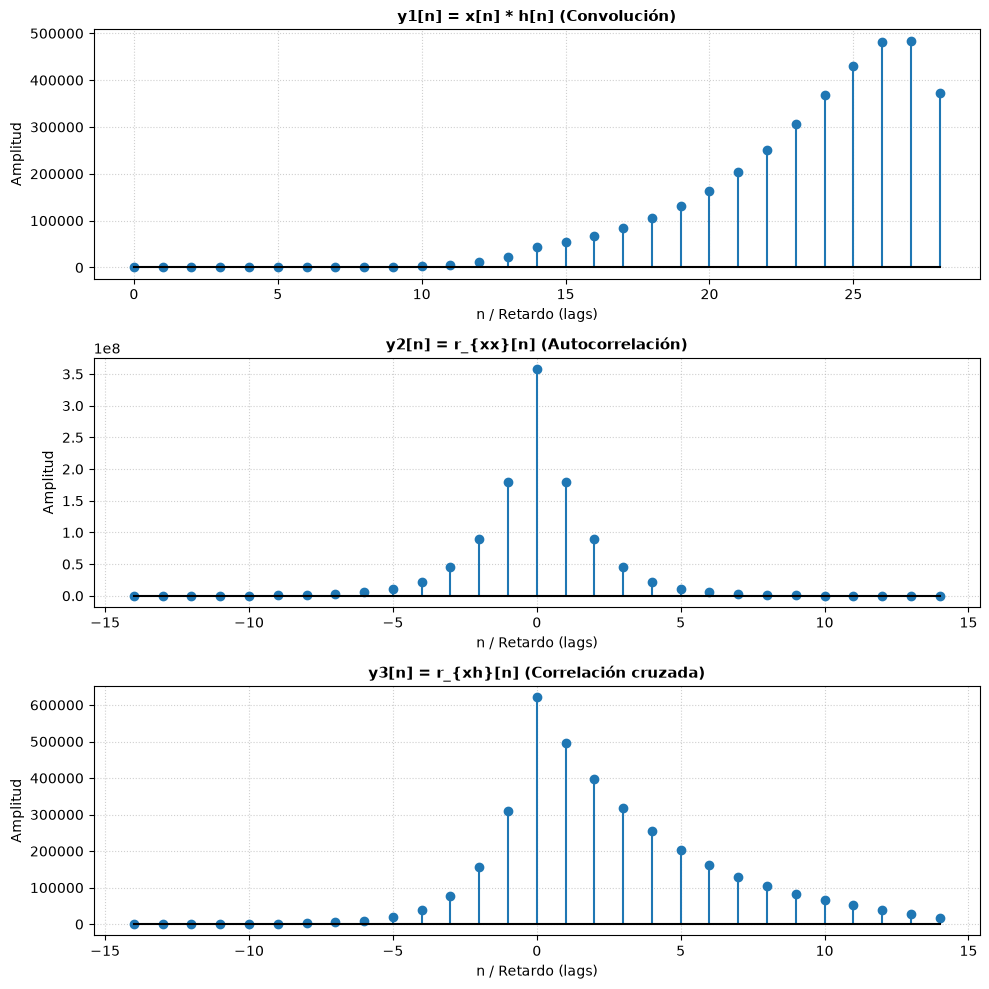

In [11]:
import matplotlib.pyplot as plt
import numpy as np

a = 0.5
b = 0.8

n_range = np.arange(0, 15)
lags = np.arange(-(len(n_range) - 1), len(n_range))


def x_sig(n):
  return (a ** (-n)) * (n >= 0).astype(float)

def h_sig(n):
  return (b ** (-n)) * (n >= 0).astype(float)

x = x_sig(n_range)
h = h_sig(n_range)

y1 = np.convolve(x, h, mode="full")
n_y1 = np.arange(2 * n_range[0], 2 * n_range[0] + len(y1))

y2 = np.correlate(x, x, mode="full")

y3 = np.correlate(x, h, mode="full")

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

titulos = [
    r"y1[n] = x[n] * h[n] (Convolución)",
    r"y2[n] = r_{xx}[n] (Autocorrelación)",
    r"y3[n] = r_{xh}[n] (Correlación cruzada)",
]

datos_grafica = [(n_y1, y1), (lags, y2), (lags, y3)]

for ax, (n_dom, sig), title in zip(axes, datos_grafica, titulos):
  ax.stem(n_dom, sig, basefmt="k-")
  ax.set_title(title, fontsize=11, fontweight="bold")
  ax.set_xlabel("n / Retardo (lags)")
  ax.set_ylabel("Amplitud")
  ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

       TEST DE COMPROBACION - RESPUESTAS              
1. ¿Por qué la autocorrelación detecta periodicidad o patrones repetitivos?
   -> Mide la similitud de una señal consigo misma en diferentes instantes.
      Si la señal es periódica, la autocorrelación presentará picos máximos
      cada vez que el desplazamiento coincida con un múltiplo del periodo.

2. Uso de correlación cruzada para determinar el desplazamiento:
   -> Si x[n] es una versión desplazada de h[n], su correlación cruzada
      tendrá un pico máximo global. El índice (lag) donde ocurre este pico
      indica exactamente la cantidad de muestras de desplazamiento.

3. Relación del resultado con x[n - n0] * h[n] y posición temporal:
   -> Debido a la propiedad de invariancia en el tiempo de los sistemas LTI,
      el resultado es y[n - n0]. La posición temporal de la salida simplemente
      se retrasa (o adelanta) en la misma cantidad n0 que la entrada.

4. Significado físico de y[n] = x[n] * h[n]:
   -> Representa la 

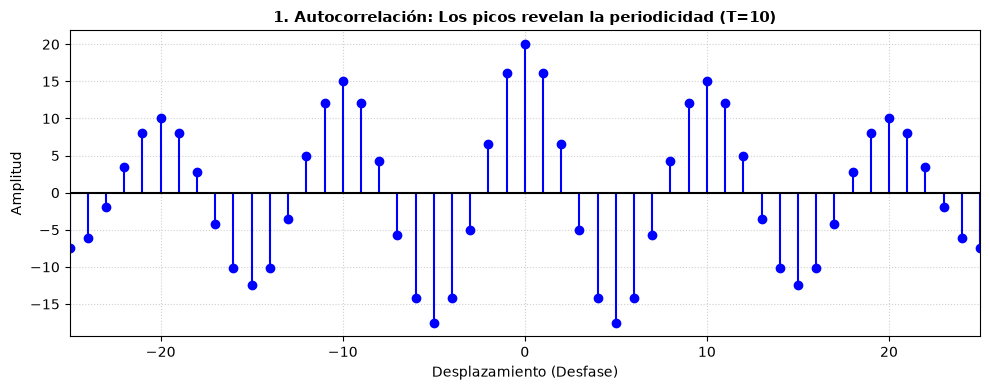

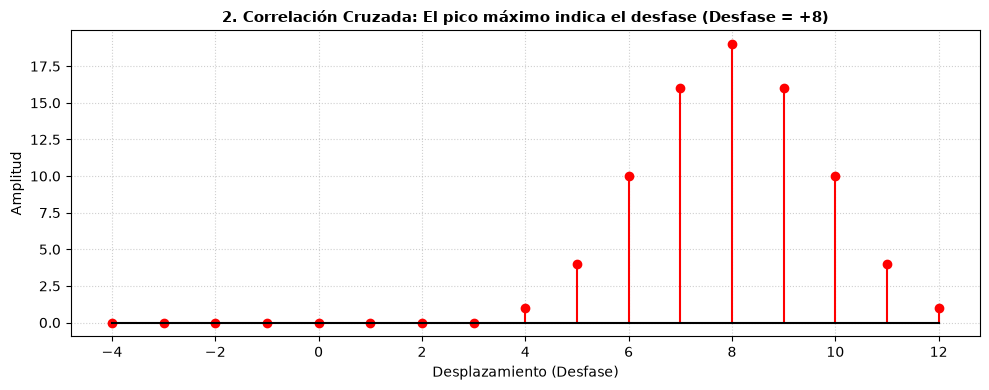

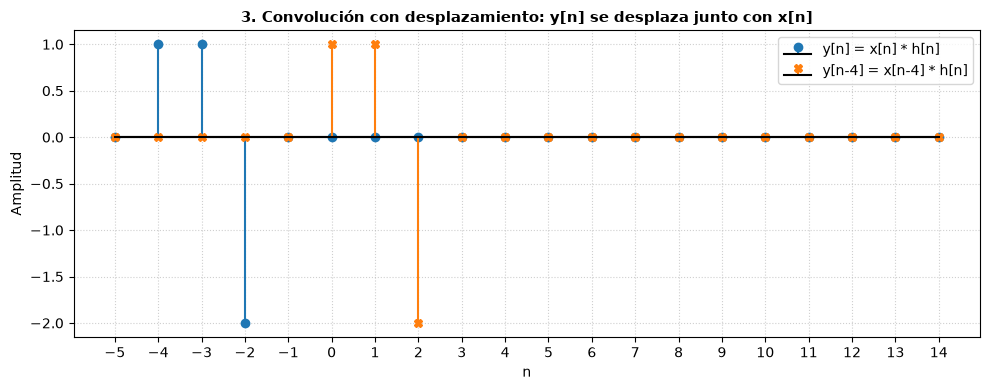

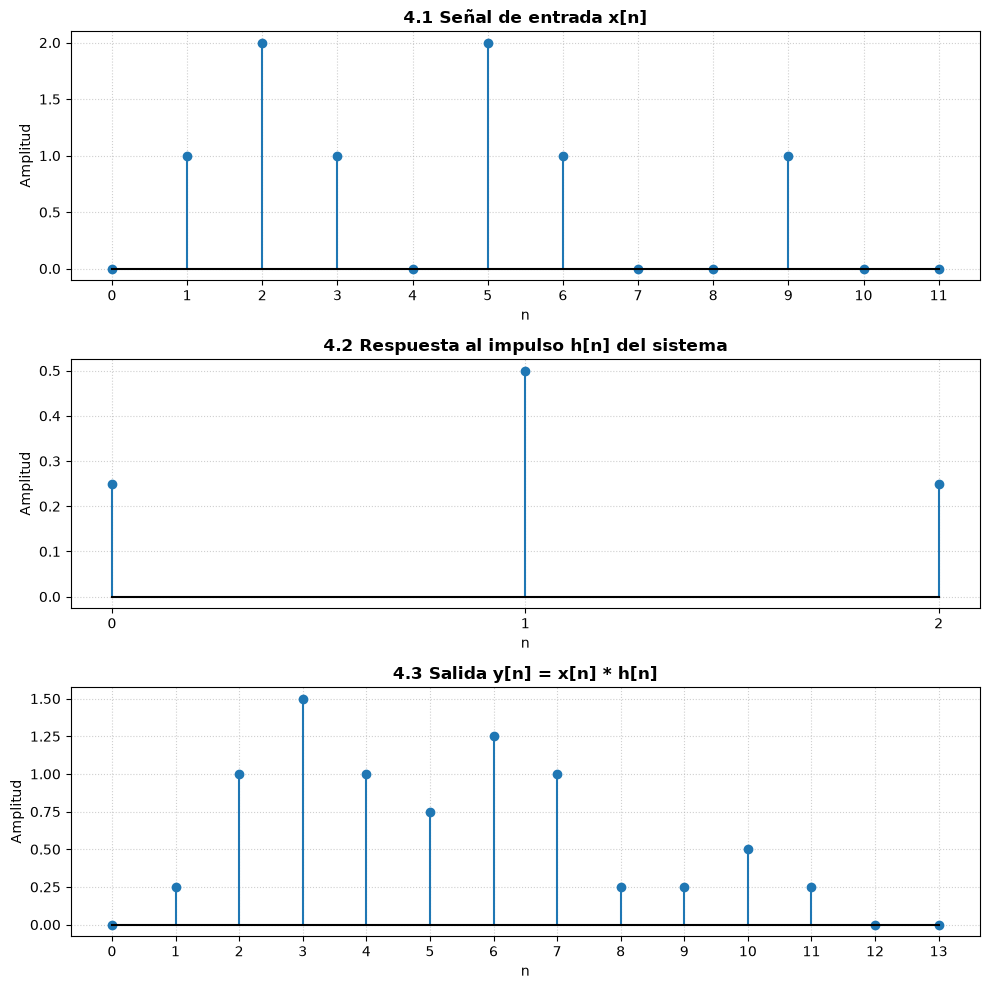

In [5]:
import matplotlib.pyplot as plt
import numpy as np

print("======================================================")
print("       TEST DE COMPROBACION - RESPUESTAS              ")
print("======================================================")

print("1. ¿Por qué la autocorrelación detecta periodicidad o patrones repetitivos?")
print("   -> Mide la similitud de una señal consigo misma en diferentes instantes.")
print("      Si la señal es periódica, la autocorrelación presentará picos máximos")
print("      cada vez que el desplazamiento coincida con un múltiplo del periodo.")

print("\n2. Uso de correlación cruzada para determinar el desplazamiento:")
print("   -> Si x[n] es una versión desplazada de h[n], su correlación cruzada")
print("      tendrá un pico máximo global. El índice (lag) donde ocurre este pico")
print("      indica exactamente la cantidad de muestras de desplazamiento.")

print("\n3. Relación del resultado con x[n - n0] * h[n] y posición temporal:")
print("   -> Debido a la propiedad de invariancia en el tiempo de los sistemas LTI,")
print("      el resultado es y[n - n0]. La posición temporal de la salida simplemente")
print("      se retrasa (o adelanta) en la misma cantidad n0 que la entrada.")

print("\n4. Significado físico de y[n] = x[n] * h[n]:")
print("   -> Representa la respuesta completa de un sistema Lineal Invariante en el")
print("      Tiempo (LTI) a una señal de entrada x[n], donde h[n] caracteriza al")
print("      sistema (su respuesta al impulso).")
print("======================================================\n")

n_per = np.arange(0, 40)

x_per = np.sin(2 * np.pi * (1/10) * n_per) 
autocorr = np.correlate(x_per, x_per, mode='full')
lags_auto = np.arange(-len(x_per) + 1, len(x_per))

plt.figure(figsize=(10, 4))
plt.stem(lags_auto, autocorr, basefmt="k-", markerfmt="bo", linefmt="b-")
plt.title("1. Autocorrelación: Los picos revelan la periodicidad (T=10)", fontsize=11, fontweight="bold")
plt.xlabel("Desplazamiento (Desfase)")
plt.ylabel("Amplitud")
plt.grid(True, linestyle=":", alpha=0.6)
plt.xlim(-25, 25)
plt.tight_layout()
plt.show()

h_base = np.array([1, 2, 3, 2, 1])

x_desplazada = np.pad(h_base, (8, 0), 'constant') 
crosscorr = np.correlate(x_desplazada, h_base, mode='full')
lags_cross = np.arange(-len(h_base) + 1, len(x_desplazada))

plt.figure(figsize=(10, 4))
plt.stem(lags_cross, crosscorr, basefmt="k-", markerfmt="ro", linefmt="r-")
plt.title("2. Correlación Cruzada: El pico máximo indica el desfase (Desfase = +8)", fontsize=11, fontweight="bold")
plt.xlabel("Desplazamiento (Desfase)")
plt.ylabel("Amplitud")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

n_conv = np.arange(-5, 15)
x_conv = (n_conv == 0).astype(float) + 2*(n_conv == 1).astype(float)
h_conv = (n_conv == 0).astype(float) - (n_conv == 1).astype(float)

y_original = np.convolve(x_conv, h_conv, mode='same')

x_conv_shifted = (n_conv == 4).astype(float) + 2*(n_conv == 5).astype(float)
y_desplazada = np.convolve(x_conv_shifted, h_conv, mode='same')

plt.figure(figsize=(10, 4))
plt.stem(n_conv, y_original, linefmt='C0-', markerfmt='C0o', basefmt="k-", label="y[n] = x[n] * h[n]")
plt.stem(n_conv, y_desplazada, linefmt='C1-', markerfmt='C1X', basefmt="k-", label="y[n-4] = x[n-4] * h[n]")
plt.title("3. Convolución con desplazamiento: y[n] se desplaza junto con x[n]", fontsize=11, fontweight="bold")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.xticks(n_conv)
plt.tight_layout()
plt.show()

n_x = np.arange(0, 12)
x = np.array([0, 1, 2, 1, 0, 2, 1, 0, 0, 1, 0, 0], dtype=float)

h = np.array([0.25, 0.5, 0.25])
n_h = np.arange(0, len(h))

y = np.convolve(x, h, mode='full')
n_y = np.arange(0, len(y))

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

axes[0].stem(n_x, x, basefmt='k-')
axes[0].set_title('4.1 Señal de entrada x[n]', fontweight='bold')
axes[0].set_xlabel('n')
axes[0].set_ylabel('Amplitud')
axes[0].set_xticks(n_x)
axes[0].grid(True, linestyle=":", alpha=0.6)

axes[1].stem(n_h, h, basefmt='k-')
axes[1].set_title('4.2 Respuesta al impulso h[n] del sistema', fontweight='bold')
axes[1].set_xlabel('n')
axes[1].set_ylabel('Amplitud')
axes[1].set_xticks(n_h)
axes[1].grid(True, linestyle=":", alpha=0.6)

axes[2].stem(n_y, y, basefmt='k-')
axes[2].set_title('4.3 Salida y[n] = x[n] * h[n]', fontweight='bold')
axes[2].set_xlabel('n')
axes[2].set_ylabel('Amplitud')
axes[2].set_xticks(n_y)
axes[2].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()